# Clustering analysis

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astroExplain.spectra.astronomy import BPT, get_subclass_summary
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

In [2]:
def map_to_dict(df, name, color, offsets):
    """
    Helper function to map a DataFrame to the expected dictionary format for plotting.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    name (str): The name of the dataset.
    color (str): The color to use for plotting.
    offsets (list of tuple): The offsets for the annotations.

    Returns:
    dict: A dictionary containing the mapped data.
    """
    return {
        "name": name,
        "color": color,
        "cluster_id": df["cluster_id"].values,
        "offsets": offsets or {},
        "n2_ha_med": df["n2_ha_med"].values,
        "n2_ha_p45": df["n2_ha_p45"].values,
        "n2_ha_p55": df["n2_ha_p55"].values,
        "o3_hb_med": df["o3_hb_med"].values,
        "o3_hb_p45": df["o3_hb_p45"].values,
        "o3_hb_p55": df["o3_hb_p55"].values,
    }

# Config

## Directories

In [3]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

clusters_meta_dirs_dict = {
    'se': f'{clustering_dir}/bin_03/mse/metadata.csv.gz',
    'iforest': f'{clustering_dir}/bin_03/iforest/metadata.csv.gz',
    'lof': f'{clustering_dir}/bin_03/lof/metadata.csv.gz'
}

## Data

In [4]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
se_df = pd.read_csv(clusters_meta_dirs_dict['se'], index_col="specobjid")
iforest_df = pd.read_csv(
    clusters_meta_dirs_dict['iforest'], index_col="specobjid"
)
lof_df = pd.read_csv(clusters_meta_dirs_dict['lof'], index_col="specobjid")

# Coordinates

In [5]:
# get SE clusters 1, 2, 3 and 4
se_ratios_df = BPT.median_45_55_ratios(se_df)
se_cluster_mask = se_ratios_df["cluster_id"].isin([1, 2, 3, 4])
se_ratios_df = se_ratios_df[se_cluster_mask]

# get iforest clusters 0, 1, 2 and 3
iforest_ratios_df = BPT.median_45_55_ratios(iforest_df)
iforest_cluster_mask = iforest_ratios_df["cluster_id"].isin([0, 1, 2, 3])
iforest_ratios_df = iforest_ratios_df[iforest_cluster_mask]

# get lof clusters 0, 2, 3
lof_ratios_df = BPT.median_45_55_ratios(lof_df)
lof_cluster_mask = lof_ratios_df["cluster_id"].isin([0, 2, 3])
lof_ratios_df = lof_ratios_df[lof_cluster_mask]

In [6]:
lof_ratios_df

,cluster_id,n2_ha_med,o3_hb_med,n2_ha_p45,n2_ha_p55,o3_hb_p45,o3_hb_p55
0,0,0.258097,1.402430,0.248957,0.277448,1.360764,1.463931
2,2,0.344494,0.894205,0.329880,0.361289,0.753847,0.982641
3,3,0.248912,2.537189,0.231673,0.274423,2.311648,2.974332


# SE BPT

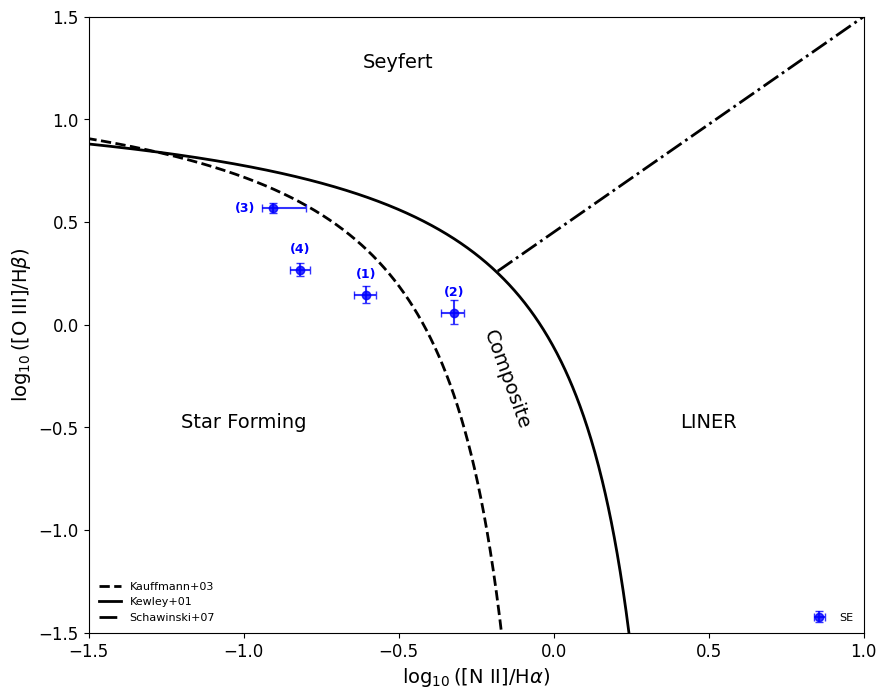

In [ ]:
se_offsets = {
    1: (0, 15),
    2: (0, 15),
    3: (-20, 0),
    4: (0, 15),
}
datasets = [map_to_dict(se_ratios_df, "SE", "blue", se_offsets)]
fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.multi_dataset_bpt_plot(fig, ax, datasets, xytext=(-5, 5))
plt.show()
# # save fig
# fname = 'bpt_se_clusters'
# fig.savefig(f"{ch_6_dir}/{fname}.pdf", bbox_inches="tight")

# Latent BPT

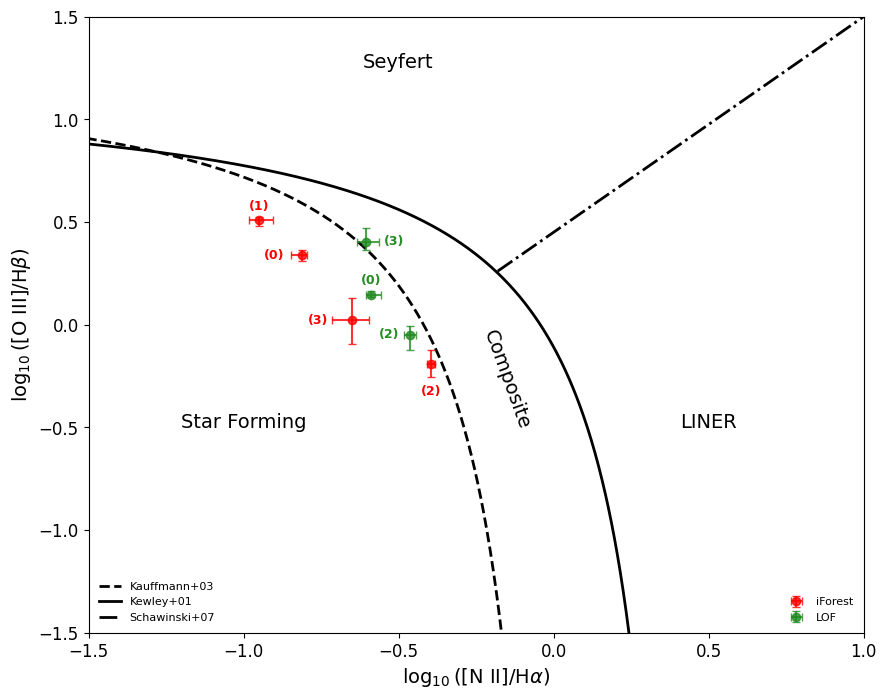

In [ ]:
iforest_offsets = {
    0: (-20, 0),
    1: (0, 10),
    2: (0, -20),
    3: (-25, 0),
}
lof_offsets = {
    0: (0, 10),
    2: (-15, 0),
    3: (20, 0),
}
datasets = [
    map_to_dict(iforest_ratios_df, "iForest", "red", iforest_offsets),
    map_to_dict(lof_ratios_df, "LOF", "forestgreen", lof_offsets)
]

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.multi_dataset_bpt_plot(fig, ax, datasets, xytext=(-5, 5))
plt.show()

# # save fig
# fname = 'bpt_latent_clusters'
# fig.savefig(f"{ch_6_dir}/{fname}.pdf", bbox_inches="tight")

# SDSS class

In [41]:
# Define target row order and mapping
subclass_order = [
    "STARFORMING",
    "STARBURST",
    "STARFORMING BROADLINE",
    "STARBURST BROADLINE",
    "AGN",
    "AGN BROADLINE",
    "BROADLINE",
    "UNDEFINED",
    "Total",
]

cluster_dfs = {}
clusters = [1, 2, 3, 4]

for c_id in clusters:

    cluster_mask = cluster_meta_df["cluster"] == c_id
    metadata_df = cluster_meta_df.loc[cluster_mask]
    df_c = get_subclass_summary(metadata_df)

    # 1. Map 'nan' string / NaN values to 'UNDEFINED'
    df_c["subClass"] = df_c["subClass"].replace({"nan": "UNDEFINED", None: "UNDEFINED"})

    # 2. Set 'subClass' as index to align across clusters
    df_c = df_c.set_index("subClass")

    # 3. Ensure all categories are present, filling missing with 0
    df_c = df_c.reindex(subclass_order).fillna(0)

    # Recompute Total row to ensure accurate sums
    df_c.loc["Total", "count"] = df_c.drop("Total")["count"].sum()
    df_c.loc["Total", "pct"] = df_c.drop("Total")["pct"].sum()

    # Format counts as integers
    df_c["count"] = df_c["count"].astype(int)

    cluster_dfs[f"Cluster {c_id}"] = df_c

# 4. Concatenate with MultiIndex columns (Cluster level on top)
combined_df = pd.concat(cluster_dfs, axis=1)
combined_df.index.name = "subClass"
combined_df.to_clipboard(excel=True, index=True)
combined_df

Cluster 1           Cluster 2           Cluster 3  \
                          count       pct     count       pct     count   
subClass                                                                  
STARFORMING                  22  0.040741        29  0.100694        13   
STARBURST                   485  0.898148       166  0.576389       171   
STARFORMING BROADLINE         2  0.003704         3  0.010417         0   
STARBURST BROADLINE           6  0.011111         3  0.010417         0   
AGN                          13  0.024074        58  0.201389        70   
AGN BROADLINE                 0  0.000000        11  0.038194        11   
BROADLINE                     0  0.000000         4  0.013889         0   
UNDEFINED                    12  0.022222        14  0.048611         3   
Total                       540  1.000000       288  1.000000       268   

                                Cluster 4            
                            pct     count       pct  
subClass                                             
STARFORMING            0.048507        54  0.177632  
STARBURST              0.638060       240  0.789474  
STARFORMING BROADLINE  0.000000         0  0.000000  
STARBURST BROADLINE    0.000000         0  0.000000  
AGN                    0.261194         2  0.006579  
AGN BROADLINE          0.041045         0  0.000000  
BROADLINE              0.000000         0  0.000000  
UNDEFINED              0.011194         8  0.026316  
Total                  1.000000       304  1.000000